This code permit you to test at the same time all the models you've computed so far. You need to make sure that all your models have a similar structure !

In [1]:
import torch
from flip.models import load_model
from flip.attacks import pgd
from flip.train import StandardTrainer, FLIPTrainer, AdversarialTrainer, TVTrainer
from flip.load_data import load_MNIST_test, load_MNIST, split_loader
from flip.utils.config import cfg, dataset, model_attributes
from flip.test import attack_model, test_acc
import numpy as np
import matplotlib.pyplot as plt
import time 
import os


In [2]:
def list_files_in_folder(folder_name):
    try:
        # Get a list of all items in the folder
        items = os.listdir(folder_name)
        
        # Filter out directories, keeping only files
        files = [item for item in items if os.path.isfile(os.path.join(folder_name, item))]
        
        return files
    
    except FileNotFoundError:
        return f"The folder '{folder_name}' does not exist."
    except Exception as e:
        return str(e)
    

In [3]:
# In this cell you can find the parameter that would be interesting to change

dataset_name = 'MNIST'

folder_name = '../../weights'

file_list = list_files_in_folder(folder_name)

print('--------------------all file computed----------------------')
print(file_list)

CFG = cfg(data=dataset(name=dataset_name, download = False), 
          model = model_attributes(
              name = 'FC', 
              sizes=[784, 200, 80, 10],
              act_fun = 'ReLU',
              file_name = '.pth',
              )
          )

# split data
dataloader, validation_loader, test_loader = split_loader(CFG, train_split=0.8)


--------------------all file computed----------------------
['model_compare_STA_v1723020814.pth', 'model_compare_SUM_v1723020814.pth', 'model_compare_adv_v1723020812.pth', 'model_compare_pTV_v1723020812.pth', 'model_compare_adv_v1723020814.pth', 'model_compare_pTV_v1723020810.pth', 'model_compare_TV_v1723020812.pth', 'model_compare_TV_v1723020814.pth', 'model_compare_TV_v1723020810.pth', 'model_compare_STA_v1723020810.pth', 'model_compare_SUM_v1723020810.pth', 'model_compare_STA_v1723020812.pth', 'model_compare_SUM_v1723020812.pth', 'model_compare_adv_v1723020810.pth', 'model_compare_pTV_v1723020814.pth']


In [4]:
models = []

for i in range(len(file_list)):
    current_file = file_list[i]
    CFG.model.file_name = current_file
    models.append((load_model.load(CFG),current_file))
    


In [5]:
def test_adversarial(epsilon_list, model_list, attack_type, loader = test_loader):
    lenghts = len(epsilon_list)
    n_models = len(model_list)
    acc_list = [[0]*lenghts for _ in range(n_models)]
    for e in range(lenghts):
        for i in range(n_models):
            model = model_list[i][0]
            acc_list[i][e] += attack_model(model, loader, attack_kwargs = {'type': attack_type, 'epsilon': epsilon_list[e]})
    name_list = [model_list[i][1] for i in range(n_models)]
    return(acc_list, name_list)

In [6]:
# In this cell you can find the parameter that would be interesting to change
lenght = 20 # lenght of epsilon list
epsilon_test_list = np.logspace(-3, -0.2, lenght)
adversarial_test = "pgd" # "fgsm"



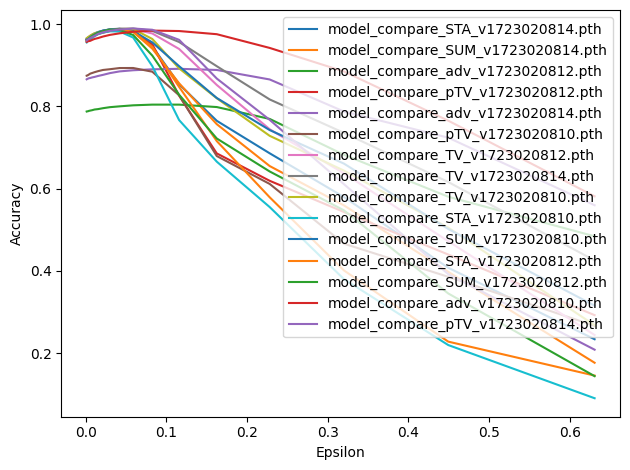

In [7]:
acc, name = test_adversarial(epsilon_test_list, models, adversarial_test, loader = test_loader)

for i in range(len(name)):
    plt.plot(epsilon_test_list, acc[i], label=name[i])

plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# training and testing accuracy

for i in range(len(file_list)):
    model = models[i][0]
    print( 'Model file : ' + models[i][1] + ' training accuracy value : ')
    print(test_acc(model, dataloader))
    print( 'Model file : ' + models[i][1] + ' testing accuracy value : ')
    print(test_acc(model, test_loader))

Model file : model_compare_STA_v1723020814.pth training accuracy value : 
tensor(0.9685)
Model file : model_compare_STA_v1723020814.pth testing accuracy value : 
tensor(0.9620)
Model file : model_compare_SUM_v1723020814.pth training accuracy value : 
tensor(0.9679)
Model file : model_compare_SUM_v1723020814.pth testing accuracy value : 
tensor(0.9594)
Model file : model_compare_adv_v1723020812.pth training accuracy value : 
tensor(0.7851)
Model file : model_compare_adv_v1723020812.pth testing accuracy value : 
tensor(0.7872)
Model file : model_compare_pTV_v1723020812.pth training accuracy value : 
tensor(0.9675)
Model file : model_compare_pTV_v1723020812.pth testing accuracy value : 
tensor(0.9606)
Model file : model_compare_adv_v1723020814.pth training accuracy value : 
tensor(0.8673)
Model file : model_compare_adv_v1723020814.pth testing accuracy value : 
tensor(0.8652)
Model file : model_compare_pTV_v1723020810.pth training accuracy value : 
tensor(0.8796)
Model file : model_compare

In [9]:
# adversarial accuracy 

attack_kwarg = {'type': 'fgsm', 'epsilon': 0.2}

for i in range(len(file_list)):
    model = models[i][0]
    print( 'Model file : ' + models[i][1] + ' training accuracy value : ')
    print(attack_model(model, test_loader, attack_kwargs = attack_kwarg))
    print( 'Model file : ' + models[i][1] + ' testing accuracy value : ')
    print(test_acc(model, test_loader))
          
attack_kwarg = {'type': 'pgd', 'epsilon': 0.1}

for i in range(len(file_list)):
    model = models[i][0]
    print( 'Model file : ' + models[i][1] + ' training accuracy value : ')
    print(attack_model(model, test_loader, attack_kwargs = attack_kwarg))
    print( 'Model file : ' + models[i][1] + ' testing accuracy value : ')
    print(test_acc(model, test_loader))

Model file : model_compare_STA_v1723020814.pth training accuracy value : 
tensor(0.0007)
Model file : model_compare_STA_v1723020814.pth testing accuracy value : 
tensor(0.9620)
Model file : model_compare_SUM_v1723020814.pth training accuracy value : 
tensor(0.0031)
Model file : model_compare_SUM_v1723020814.pth testing accuracy value : 
tensor(0.9594)
Model file : model_compare_adv_v1723020812.pth training accuracy value : 
tensor(0.1936)
Model file : model_compare_adv_v1723020812.pth testing accuracy value : 
tensor(0.7872)
Model file : model_compare_pTV_v1723020812.pth training accuracy value : 
tensor(0.0187)
Model file : model_compare_pTV_v1723020812.pth testing accuracy value : 
tensor(0.9606)
Model file : model_compare_adv_v1723020814.pth training accuracy value : 
tensor(0.1688)
Model file : model_compare_adv_v1723020814.pth testing accuracy value : 
tensor(0.8652)
Model file : model_compare_pTV_v1723020810.pth training accuracy value : 
tensor(0.0201)
Model file : model_compare